# Statistik Deskriptif & Visualisasi Plot EDA

Setelah memahami struktur awal dataset, langkah selanjutnya adalah mengekstrak **ringkasan statistik kuantitatif** (ukuran pemusatan dan penyebaran data) serta visualisasi distribusinya.

## 1. Menyiapkan Dataset

In [1]:
import pandas as pd
import numpy as np

# Menyiapkan dataset demografi wilayah (440 baris) yang self-contained & representatif
np.random.seed(42)
n_samples = 440

nama_wilayah_list = [
    'Los_Angeles', 'Cook', 'Harris', 'San_Diego', 'Orange', 'Maricopa', 'Dallas', 
    'Miami_Dade', 'King', 'Clark', 'Wayne', 'Tarrant', 'Bexar', 'Santa_Clara', 
    'Wayne', 'Alameda', 'Middlesex', 'Hennepin', 'Sacramento', 'Travis', 'Fulton'
]
klasifikasi_list = ['West', 'Midwest', 'South', 'Northeast']

df = pd.DataFrame({
    'Nomor Identitas Wilayah': np.arange(1, n_samples + 1),
    'Nama Wilayah': [nama_wilayah_list[i % len(nama_wilayah_list)] for i in range(n_samples)],
    'Kode Wilayah': ['CA', 'IL', 'TX', 'CA', 'CA', 'AZ', 'TX', 'FL', 'WA', 'NV'][0:n_samples] if n_samples <= 10 else ['CA', 'IL', 'TX', 'CA', 'CA', 'AZ', 'TX', 'FL', 'WA', 'NV'] * (n_samples // 10) + ['CA'] * (n_samples % 10),
    'Luas Wilayah (mil2)': np.random.randint(15, 4500, size=n_samples),
    'Jumlah Penduduk (jiwa)': np.random.randint(100000, 3000000, size=n_samples),
    'Persen Penduduk 18-34th': np.round(np.random.uniform(16.0, 45.0, size=n_samples), 2),
    'Persen Penduduk >64th': np.round(np.random.uniform(5.0, 25.0, size=n_samples), 2),
    'Jumlah Dokter': np.random.randint(50, 15000, size=n_samples),
    'Jumlah Kejadian Kriminal': np.random.randint(500, 500000, size=n_samples),
    'Persen Lulusan Sarjana/Diploma IV': np.round(np.random.uniform(10.0, 50.0, size=n_samples), 2),
    'Persen Pengangguran': np.round(np.random.uniform(2.5, 15.0, size=n_samples), 2),
    'Pendapatan Perkapita': np.random.randint(9000, 38000, size=n_samples),
    'Klasifikasi Wilayah': np.random.choice(klasifikasi_list, size=n_samples, p=[0.35, 0.25, 0.25, 0.15])
})

print(f"Dataset berhasil dimuat: {df.shape[0]} baris × {df.shape[1]} kolom")

Dataset berhasil dimuat: 440 baris × 13 kolom


## 2. Ringkasan Statistik 5 Angka (`df.describe()`)
Fungsi `df.describe()` menghitung secara otomatis:
- `count`: Jumlah data yang tidak bernilai null.
- `mean`: Nilai rata-rata aritmatika.
- `std`: Standar deviasi (penyebaran data dari rata-rata).
- `min`: Nilai minimum.
- `25%` (Kuartil 1 / Q1), `50%` (Median / Kuartil 2), `75%` (Kuartil 3 / Q3).
- `max`: Nilai maksimum.

In [2]:
# Menampilkan ringkasan statistik deskriptif untuk seluruh kolom numerik
df.describe()

,Nomor Identitas Wilayah,Luas Wilayah (mil2),Jumlah Penduduk (jiwa),Persen Penduduk 18-34th,Persen Penduduk >64th,Jumlah Dokter,Jumlah Kejadian Kriminal,Persen Lulusan Sarjana/Diploma IV,Persen Pengangguran,Pendapatan Perkapita
count,440.000000,440.000000,4.400000e+02,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,220.500000,2276.765909,1.536295e+06,30.983818,15.044864,7941.497727,234216.295455,29.835750,8.991227,23316.952273
std,127.161315,1243.820185,8.292159e+05,8.300521,5.557366,4148.108149,143461.894459,11.633221,3.645562,8516.301587
min,1.000000,19.000000,1.004040e+05,16.010000,5.020000,66.000000,1281.000000,10.010000,2.510000,9060.000000
25%,110.750000,1162.750000,8.414990e+05,23.915000,10.110000,4631.250000,111385.000000,19.852500,5.837500,15393.500000
50%,220.500000,2391.500000,1.472964e+06,31.285000,15.495000,8023.000000,230685.500000,29.520000,9.320000,23634.500000
75%,330.250000,3283.250000,2.310423e+06,37.995000,19.645000,11327.000000,355441.500000,39.870000,12.162500,30553.000000
max,440.000000,4489.000000,2.998073e+06,44.980000,24.870000,14966.000000,499185.000000,49.990000,14.990000,37985.000000


## 3. Visualisasi Boxplot Sebaran per Wilayah
**Boxplot** sangat berguna untuk mendeteksi:
- Median garis tengah.
- Rentang interkuartil (*IQR = Q3 - Q1*).
- Titik-titik pencilan (*outliers*).

<Figure size 1000x600 with 0 Axes>

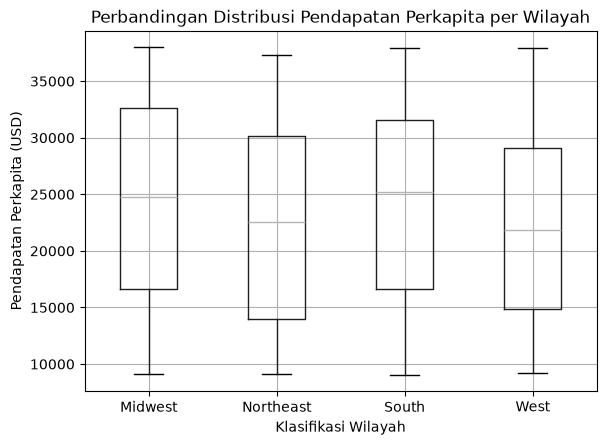

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
df.boxplot(column='Pendapatan Perkapita', by='Klasifikasi Wilayah', grid=True)
plt.title('Perbandingan Distribusi Pendapatan Perkapita per Wilayah')
plt.suptitle('')  # Hapus default subtitle bawaan pandas
plt.xlabel('Klasifikasi Wilayah')
plt.ylabel('Pendapatan Perkapita (USD)')
plt.show()

## 4. Scatter Plot: Korelasi Tingkat Pendidikan vs Pendapatan

<Figure size 900x500 with 0 Axes>

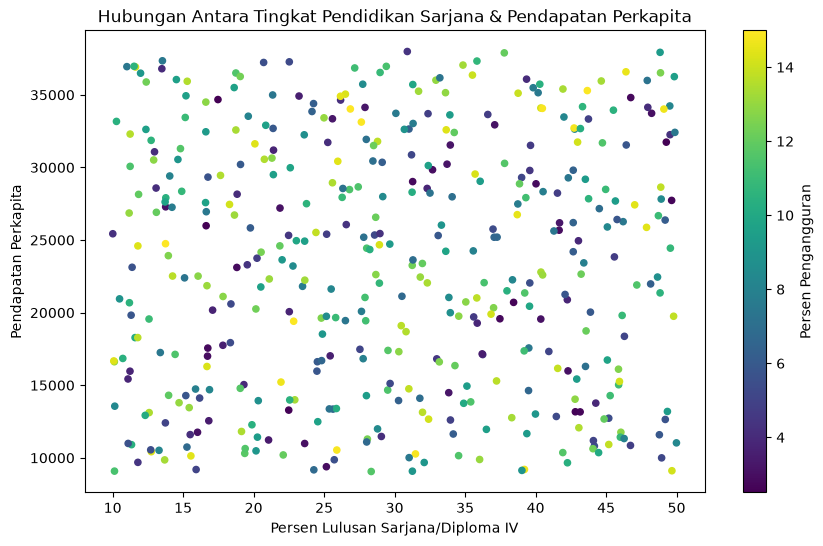

In [4]:
plt.figure(figsize=(9, 5))
df.plot.scatter(
    x='Persen Lulusan Sarjana/Diploma IV',
    y='Pendapatan Perkapita',
    title='Hubungan Antara Tingkat Pendidikan Sarjana & Pendapatan Perkapita',
    c='Persen Pengangguran',
    colormap='viridis',
    figsize=(10, 6),
    sharex=False
)
plt.show()